In [ ]:
include("dependencies.jl")
include("system_params.jl")
include("functions.jl")

┌ Warning: attempting to remove probably stale pidfile
│   path = "/amd/home/agfleischhauer/roq68sum/.julia/compiled/v1.11/DiffEqBase/oaevG_Y651M.ji.pidfile"
└ @ FileWatching.Pidfile /amd/home/agfleischhauer/roq68sum/.julia/juliaup/julia-1.11.3+0.x64.linux.gnu/share/julia/stdlib/v1.11/FileWatching/src/pidfile.jl:249
┌ Warning: Module PrecompileTools with build ID fafbfcfd-041b-44db-0006-8990f3702ebe is missing from the cache.
│ This may mean PrecompileTools [aea7be01-6a6a-4083-8856-8a6e6704d82a] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:2541
┌ Warning: attempting to remove probably stale pidfile
│   path = /amd/home/agfleischhauer/roq68sum/.julia/compiled/v1.11/DiffEqBase/oaevG_Y651M.ji.pidfile
└ @ FileWatching.Pidfile /amd/home/agfleischhauer/roq68sum/.julia/juliaup/julia-1.11.3+0.x64.linux.gnu/share/julia/stdlib/v1.11/FileWatching/src/pidfile.jl:249
┌ Warning: Module PrecompileTools with build ID fafbfcfd-78b0-4dd9-0006-899588e29266 is

In [2]:
const σ_x, n, Π_g, n, I, σ_minus, σ_plus, σ_z = system_constants()
const Ω, γ_Decay, γ_dephase, V_nn, δ, Δ1_0, T_optimal = unpack_params()

(1.0, 0.001, 0.0, -1000.0, 0.108, 1032.0, 582.0)

In [5]:
ψ0 = initialize_system()
# p1 = qubit_parameters(Ω, γ_Decay, γ_dephase, V_nn, δ)
tspan = [0.0:1:T_optimal;];

In [6]:
basis = CompositeBasis([NLevelBasis(2) for _ in 1:total_qubits]...)
ψ0_ket = Ket(basis, ComplexF64.(ψ0))   # Ensure wavefunction is a valid `Ket`

Ket(dim=8)
  basis: [NLevel(N=2) ⊗ NLevel(N=2) ⊗ NLevel(N=2)]
 0.0 + 0.0im
 0.0 + 0.0im
 1.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im

In [7]:
tout, ψt = timeevolution.mcwf_dynamic(tspan,ψ0_ket,f);

In [8]:
basis = NLevelBasis(2)
k = transition(basis,2,2)

n_a = full_operator(k,total_qubits, [1])
n_c = full_operator(k, total_qubits, [3])
n_ac = full_operator(k, total_qubits, [1,3])

pop_a = real(expect(n_a, ψt))
pop_c = real(expect(n_c, ψt));

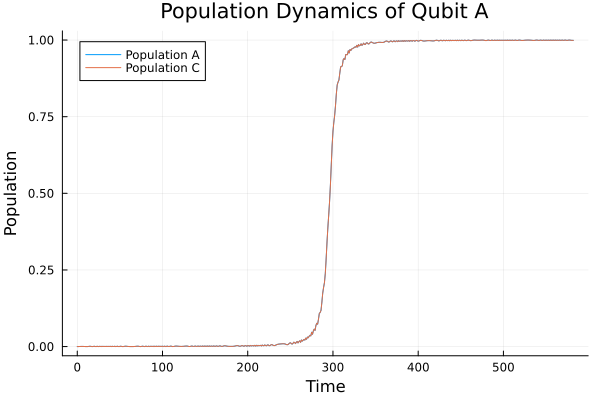

In [9]:
using Plots
plot(tout, pop_a, label="Population A", xlabel="Time", ylabel="Population", title="Population Dynamics of Qubit A")
plot!(tout, pop_c, label="Population C")

In [20]:
N_trajectories = 1
pop_a = zeros(length(tspan))
pop_c = zeros(length(tspan))

for i in 1:N_trajectories
    tout, ψt = timeevolution.mcwf_dynamic(tspan,ψ0_ket,f;alg=Rodas3(autodiff=false))
    pop_a .+= real(expect(n_a, ψt))
    pop_c .+= real(expect(n_c, ψt))
end

pop_a ./= N_trajectories
pop_c ./= N_trajectories

583-element Vector{Float64}:
 0.0
 7.105837437736182e-5
 0.00021876685268868972
 0.0003667640389568667
 0.00047594103132587236
 0.0005336978383097237
 0.0005382597322884288
 0.0004891866299343577
 0.0003868722423964444
 0.00024129136798591708
 ⋮
 0.9991032784320204
 0.9989856879233356
 0.9995539446138214
 0.9999817586959536
 0.9998497050155188
 0.9994032787812173
 0.9990410778828194
 0.9989407671433336
 0.9990553791725321

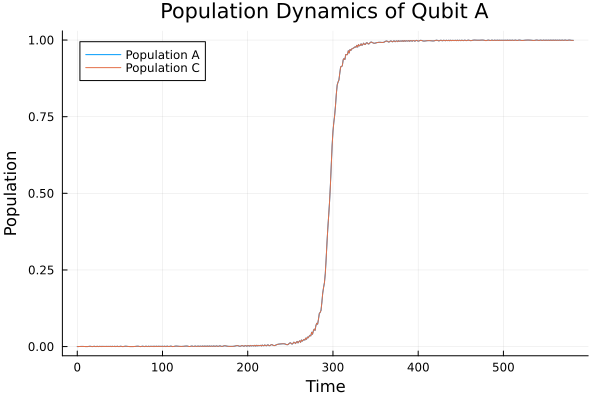

In [24]:
plot(tspan, pop_a, label="Population A", xlabel="Time", ylabel="Population", title="Population Dynamics of Qubit A")
plot!(tspan, pop_c, label="Population C")